In [169]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import KFold , cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR


In [125]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [126]:
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

In [127]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,Low,Low floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,0,0,Low,Mid floor
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,Low,High floor
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,1,0,1,High,Mid floor
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,1,0,High,Mid floor


In [128]:
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [129]:
df.sample(3)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
3359,flat,sector 81,2.30,3,4,3+,New Property,1893.0,1,0,furnished,High,Mid floor
823,flat,sector 83,1.76,3,3,3,Relatively New,1500.0,1,0,semifurnished,High,Mid floor
1737,flat,sector 28,2.00,3,3,1,Old Property,1240.0,0,0,semifurnished,Medium,High floor


In [130]:
X = df.drop(columns=['price'])
y = df['price']

<Axes: xlabel='price', ylabel='Count'>

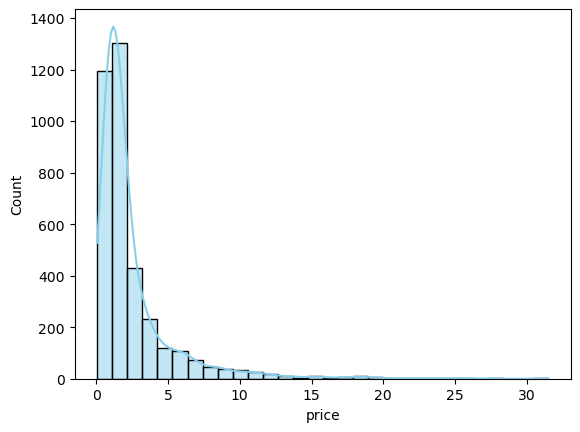

In [131]:
sns.histplot(x=df['price'],kde=True,color='skyblue',bins=30)

In [132]:
y_transformed = np.log1p(y)

# ORDINAL ENCODING

In [37]:
columns_to_encode = ['property_type','sector','balcony','agePossession','furnishing_type','luxury_category','floor_category']

In [38]:
# Creating the column transformer
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['bedRoom','bathroom','built_up_area','servant room','store room']),
        ('cat', OrdinalEncoder(), columns_to_encode)
    ],
    remainder = 'passthrough'
)

In [39]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', LinearRegression())
])

In [40]:
#K-fold Cross validation
kfold = KFold(n_splits=10, shuffle = True, random_state = 42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring = 'r2')

In [41]:
print(scores.mean(),scores.std())

0.7305186804746205 0.04107957778910802


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

In [43]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
y_pred = pipeline.predict(X_test)

In [45]:
y_pred = np.expm1(y_pred)

In [46]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.9563651243425377

In [47]:
def score (model_name,model):
    output=[]
    output.append(model_name)

    pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', model)
    ])

    kfold = KFold(n_splits=10, shuffle = True, random_state = 42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring = 'r2')

    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [48]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [50]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(score(model_name,model))


In [51]:
model_df = pd.DataFrame(model_output,columns=['name','r2','mae'])

In [52]:
model_df

,name,r2,mae
0,linear_reg,0.730519,0.956365
1,svr,0.759083,0.909834
2,ridge,0.730523,0.956341
3,LASSO,0.059697,1.593638
4,decision tree,0.792143,0.673326
5,random forest,0.883511,0.608036
6,extra trees,0.870343,0.617622
7,gradient boosting,0.872635,0.649008
8,adaboost,0.727352,1.003310
9,mlp,0.805869,0.805044


In [57]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.892997,0.595489
5,random forest,0.883511,0.608036
6,extra trees,0.870343,0.617622
7,gradient boosting,0.872635,0.649008
4,decision tree,0.792143,0.673326
9,mlp,0.805869,0.805044
1,svr,0.759083,0.909834
2,ridge,0.730523,0.956341
0,linear_reg,0.730519,0.956365
8,adaboost,0.727352,1.003310


# OneHotEncoding

In [88]:
columns_to_encode = ['property_type','balcony','agePossession','luxury_category','floor_category']

In [89]:
preprocessor = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), ['bedRoom','bathroom','built_up_area','servant room','store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1', OneHotEncoder(drop='first'),['sector','agePossession','furnishing_type'])
    ],
    remainder = 'passthrough'
)

In [90]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', LinearRegression())
])

In [91]:
kflod = KFold(n_splits = 10, shuffle = True, random_state = 42)
scores = cross_val_score(pipeline,X,y_transformed,cv=kfold,scoring='r2')

In [92]:
scores.mean()

np.float64(0.8495782275589916)

In [93]:
scores.std()

np.float64(0.030944246448202258)

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [95]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
y_pred = pipeline.predict(X_test)

In [97]:
y_pred = np.expm1(y_pred)

In [98]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.6953862989953681

In [99]:
def score (model_name,model):
    output=[]
    output.append(model_name)

    pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', model)
    ])

    kfold = KFold(n_splits=10, shuffle = True, random_state = 42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring = 'r2')

    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [100]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [101]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(score(model_name,model))

In [102]:
model_df = pd.DataFrame(model_output,columns=['model_name','r2','mae'])

In [104]:
model_df.sort_values('mae')

,model_name,r2,mae
6,extra trees,0.887676,0.555103
10,xgboost,0.895055,0.574942
9,mlp,0.876789,0.577800
5,random forest,0.876877,0.598617
1,svr,0.878823,0.630561
4,decision tree,0.791885,0.664146
7,gradient boosting,0.857342,0.683347
0,linear_reg,0.849578,0.695386
2,ridge,0.849886,0.699055
8,adaboost,0.659423,1.089028


# Target Encoder

In [105]:
!pip install category_encoders

In [147]:
import category_encoders as ce

columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),['bedRoom','bathroom','built_up_area','servant room','store room']),
        ('cat',OrdinalEncoder(),columns_to_encode),
        ('cat1',OneHotEncoder(),['agePossession']),
        ('cat2',ce.TargetEncoder(),['sector'])
    ],
    remainder = 'passthrough'
)

In [148]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [149]:
kfold = KFold(n_splits = 10, shuffle = True, random_state = 42)
scores = cross_val_score(pipeline,X,y_transformed,cv=kfold,scoring='r2')

In [150]:
scores.mean()

np.float64(0.8230348928715905)

In [151]:
scores.std()

np.float64(0.029445633060298928)

In [152]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [153]:
y_pred = pipeline.predict(X_test)

In [154]:
y_pred = np.expm1(y_pred)

In [155]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.7453698918892664

In [156]:
def score (model_name,model):
    output=[]
    output.append(model_name)

    pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', model)
    ])

    kfold = KFold(n_splits=10, shuffle = True, random_state = 42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring = 'r2')

    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [157]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [158]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(score(model_name,model))

In [159]:
model_df = pd.DataFrame(model_output,columns=['model_name','r2','mae'])

In [160]:
model_df.sort_values('mae')

,model_name,r2,mae
5,random forest,0.902478,0.537241
6,extra trees,0.901471,0.547083
10,xgboost,0.903726,0.589757
7,gradient boosting,0.888410,0.602324
9,mlp,0.847034,0.694970
4,decision tree,0.829984,0.704005
0,linear_reg,0.823035,0.745370
2,ridge,0.823056,0.745689
8,adaboost,0.776074,0.871595
1,svr,0.778220,0.879208


# Final Model

In [171]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['bedRoom','bathroom','built_up_area','servant room','store room']),
        ('cat', OrdinalEncoder(),columns_to_encode),
        ('cat1', OneHotEncoder(drop='first',sparse_output = False),['sector','agePossession'])
    ],
    remainder = 'passthrough'
    
)

In [174]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100))
])

In [175]:
pipeline.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [176]:
import pickle

In [177]:
with open('pipeline.pkl','wb') as file:
    pickle.dump(pipeline,file)

In [178]:
with open('df.pkl','wb') as file:
    pickle.dump(X,file)

In [182]:
X

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,3,2,2,New Property,850.0,0,0,unfurnished,Low,Low floor
1,flat,sector 89,2,2,2,New Property,1226.0,1,0,unfurnished,Low,Mid floor
2,flat,sohna road,2,2,1,New Property,1000.0,0,0,unfurnished,Low,High floor
3,flat,sector 92,3,4,3+,Relatively New,1615.0,1,0,semifurnished,High,Mid floor
4,flat,sector 102,2,2,1,Relatively New,582.0,0,1,unfurnished,High,Mid floor
...,...,...,...,...,...,...,...,...,...,...,...,...
3665,flat,sector 84,2,2,1,Relatively New,532.0,0,0,unfurnished,Medium,Mid floor
3666,house,sector 109,5,5,3+,Relatively New,6228.0,1,1,unfurnished,High,Low floor
3667,flat,sector 2,1,1,1,Moderately Old,665.0,0,0,semifurnished,Medium,Mid floor
3668,house,sector 43,5,6,3,Moderately Old,5490.0,1,1,unfurnished,Medium,Mid floor


In [187]:
data = [['house', 'sector 102', 2, 3, '3+', 'New Property', 2750, 0, 0, 'unfurnished', 'Low', 'Low floor']]
columns = ['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category']

# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 102,2,3,3+,New Property,2750,0,0,unfurnished,Low,Low floor


In [188]:
np.expm1(pipeline.predict(one_df))

array([2.80911992])

In [190]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3670 non-null   object 
 1   sector           3670 non-null   object 
 2   bedRoom          3670 non-null   int64  
 3   bathroom         3670 non-null   int64  
 4   balcony          3670 non-null   object 
 5   agePossession    3670 non-null   object 
 6   built_up_area    3670 non-null   float64
 7   servant room     3670 non-null   int64  
 8   store room       3670 non-null   int64  
 9   furnishing_type  3670 non-null   object 
 10  luxury_category  3670 non-null   object 
 11  floor_category   3670 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 344.2+ KB
